<a href="https://www.kaggle.com/code/vermaavi/dinov2-for-flower-classification-f1-99-6?scriptVersionId=241969496" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## Flower Classification with DINOv2 Vision Transformer

We will be using  **DINOv2** for classifying images of flowers into 102 distinct categories.

### **Why DINOv2?**
A state-of-the-art self-supervised Vision Transformer developed by Meta AI.
- **Robust Feature Extraction:** DINOv2 learns rich, generalizable visual features from unlabeled data, making it highly effective for transfer learning tasks.
- **Superior Performance:** Vision Transformers have demonstrated strong results on image classification benchmarks, especially when fine-tuned on domain-specific datasets.

### **What Will We Do?**
1. **Data Exploration & Visualization:**  
   - Inspect the dataset structure and visualize sample images to understand class distribution and data quality.
2. **Model Preparation:**  
   - Leverage a pre-trained DINOv2 model as a feature extractor.
   - Attach a classification head tailored for 102 flower classes.
3. **Training & Validation:**  
   - Fine-tune the model using the training set.
   - Monitor performance using validation data and save out best model.
4. **Evaluation:**  
   - Assess the model on the test set using accuracy and weighted F1 score.
   - Analyze misclassifications to identify potential areas for improvement.

In [1]:
# to keep tap on each cell processing time
!pip install ipython-autotime 
%load_ext autotime

time: 650 µs (started: 2025-05-26 13:43:12 +00:00)


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import os
import random
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

image_paths = []

for dirname, _, filenames in os.walk('/kaggle/input/flower-classification-dataset/Flower Classification Dataset/train'):
    for filename in filenames:
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(dirname, filename))

# Randomly pick 10 images
sampled_paths = random.sample(image_paths, 20)
print("\n".join(sampled_paths))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/flower-classification-dataset/Flower Classification Dataset/train/86/image_02891_jpg.rf.a33844a07e643267979e7f5b20750496.jpg
/kaggle/input/flower-classification-dataset/Flower Classification Dataset/train/75/image_02136_jpg.rf.3d870d6f639c1095faea7dced74892ea.jpg
/kaggle/input/flower-classification-dataset/Flower Classification Dataset/train/38/image_05825_jpg.rf.ee811ae3d5f8dbb9bada52d3e79713aa.jpg
/kaggle/input/flower-classification-dataset/Flower Classification Dataset/train/36/image_04381_jpg.rf.e00edd1504fea8ceeeee9a21e1402213.jpg
/kaggle/input/flower-classification-dataset/Flower Classification Dataset/train/51/image_01371_jpg.rf.cf22f4c89c63b0c6ceba58ca7071970e.jpg
/kaggle/input/flower-classification-dataset/Flower Classification Dataset/train/83/image_01769_jpg.rf.28d5249964324af0206356362b24bc29.jpg
/kaggle/input/flower-classification-dataset/Flower Classification Dataset/train/11/image_03172_jpg.rf.27452c6694db4c68d4098378befa5061.jpg
/kaggle/input/flower-classi

#### Confirming number of classes -
in train, valid and test data folder

In [3]:
!ls '/kaggle/input/flower-classification-dataset/Flower Classification Dataset/train' | wc -l

102
time: 121 ms (started: 2025-05-26 13:43:16 +00:00)


In [4]:
!ls '/kaggle/input/flower-classification-dataset/Flower Classification Dataset/test' | wc -l

102
time: 130 ms (started: 2025-05-26 13:43:16 +00:00)


In [5]:
!ls '/kaggle/input/flower-classification-dataset/Flower Classification Dataset/valid' | wc -l

102
time: 150 ms (started: 2025-05-26 13:43:16 +00:00)


## Visualise images

In [6]:
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

img_size = 224
# will use this to load images
def load_image(image_path):
    input_image = Image.open(image_path)
    resized_image = input_image.resize((img_size, img_size))

    return resized_image

time: 818 µs (started: 2025-05-26 13:43:17 +00:00)


In [7]:
#helper function to visualise images
import matplotlib.pyplot as plt
import math

def show_images_in_grid(images, titles=None, cols=3, figsize=(15, 8)):
    """
    Display a list of images in a grid with optional titles.

    Args:
        images (list): List of images (as NumPy arrays or loaded using PIL/mpimg).
        titles (list): Optional list of titles for each image.
        cols (int): Number of columns in the grid.
        figsize (tuple): Size of the entire figure.
    """
    n_images = len(images)
    rows = math.ceil(n_images / cols)

    fig, axs = plt.subplots(rows, cols, figsize=figsize)
    axs = axs.flatten()  # flatten in case of 2D array

    for i in range(len(axs)):
        if i < n_images:
            axs[i].imshow(load_image(images[i]))
            axs[i].axis('off')
            if titles:
                axs[i].set_title(titles[i].split('/')[-2])
        else:
            axs[i].axis('off')  # Hide empty subplots

    plt.tight_layout()
    plt.show()


time: 993 µs (started: 2025-05-26 13:43:17 +00:00)


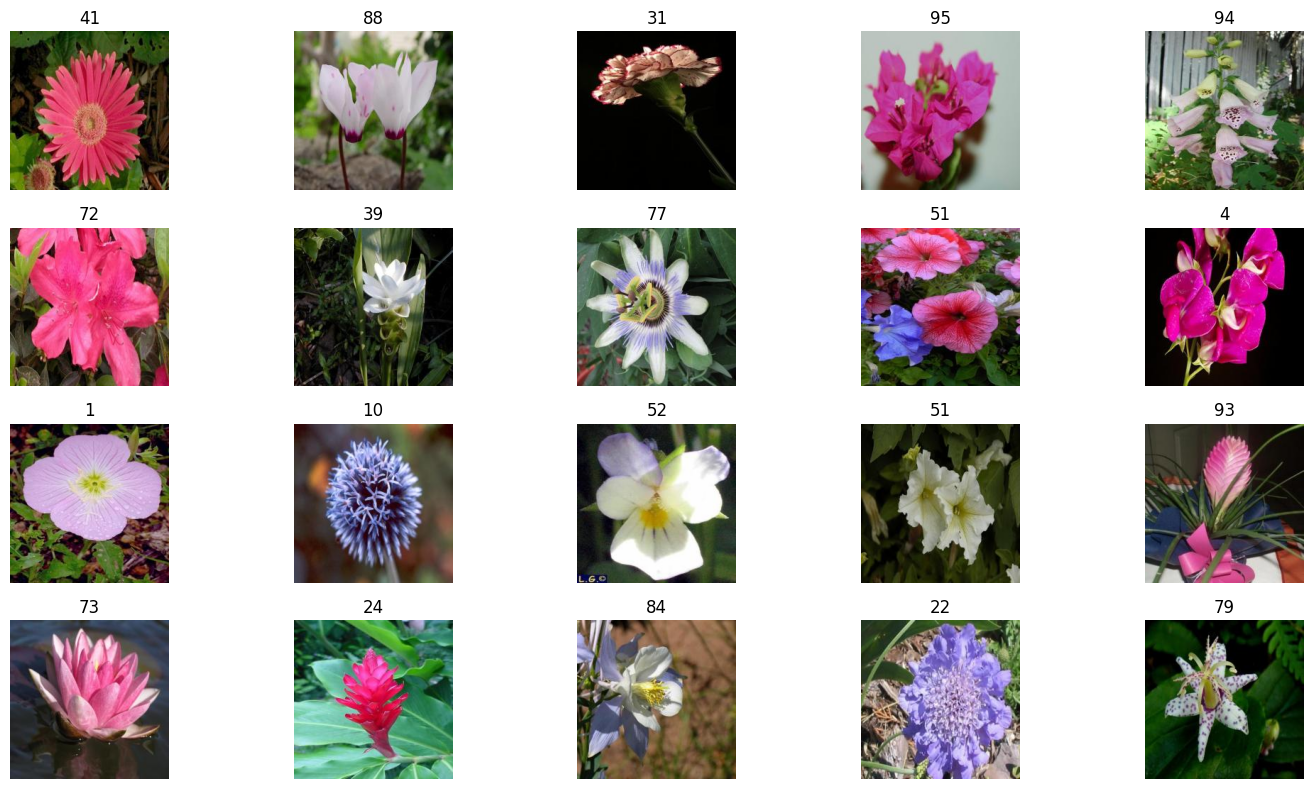

time: 1.56 s (started: 2025-05-26 13:43:17 +00:00)


In [8]:
#visualise a random samples, run this mulitple to view different sample sets
sampled_paths = random.sample(image_paths, 20)
show_images_in_grid(sampled_paths, sampled_paths, cols=5, figsize=(15, 8))

## Model fitting for classification
We will be utilizing **DINOv2**. To adapt it for our specific task of classifying 102 flower categories, we will append a classification head — a linear layer that maps the extracted features to the desired number of classes.

**Data Preparation**:
Our dataset is organized into separate directories for training, validation, and testing. Within each of these, images are further divided into subfolders named after their corresponding class labels (ranging from 0 to 101). This structure is compatible with PyTorch's ImageFolder class, facilitating straightforward data loading and preprocessing.

**Loss Function**: Cross-Entropy Loss
Given that our task is multi-class classification, Cross-Entropy Loss is an appropriate choice. It measures the discrepancy between the predicted class probabilities and the actual class labels, effectively guiding the model to improve its predictions during training.​

Optimizer: AdamW

In [9]:
#imports
import torch
from transformers import AutoImageProcessor, AutoModel, AutoModelForImageClassification
from torchvision import transforms
from sklearn.metrics.pairwise import cosine_similarity

2025-05-26 13:43:32.837897: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748267013.062153      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748267013.141167      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


time: 29.3 s (started: 2025-05-26 13:43:18 +00:00)


In [10]:
#will train over GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

time: 2.18 ms (started: 2025-05-26 13:43:48 +00:00)


In [11]:
# Load the pre-trained DINOv2 model and processor
processor = AutoImageProcessor.from_pretrained('facebook/dinov2-base')
model = AutoModelForImageClassification.from_pretrained(
    "facebook/dinov2-base",
    num_labels=102  # Set this to the number of our classes
)

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of Dinov2ForImageClassification were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


time: 7.18 s (started: 2025-05-26 13:43:48 +00:00)


In [12]:
model

Dinov2ForImageClassification(
  (dinov2): Dinov2Model(
    (embeddings): Dinov2Embeddings(
      (patch_embeddings): Dinov2PatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): Dinov2Encoder(
      (layer): ModuleList(
        (0-11): 12 x Dinov2Layer(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attention): Dinov2Attention(
            (attention): Dinov2SelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): Dinov2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (layer_scale1): Dinov2Laye

time: 2.53 ms (started: 2025-05-26 13:43:55 +00:00)


In [13]:
#prepare data loader pipeline
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

batch_size = 64   #adjust based on GPU RAM
img_size = (224, 224)

train_data_path = '/kaggle/input/flower-classification-dataset/Flower Classification Dataset/train'
valid_data_path = '/kaggle/input/flower-classification-dataset/Flower Classification Dataset/valid'
test_data_path = '/kaggle/input/flower-classification-dataset/Flower Classification Dataset/test'

# Define transformations
transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

# Load datasets
train_dataset = datasets.ImageFolder(root=train_data_path, transform=transform)
val_dataset = datasets.ImageFolder(root=valid_data_path, transform=transform)
test_dataset = datasets.ImageFolder(root=test_data_path, transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


time: 4.16 s (started: 2025-05-26 13:43:55 +00:00)


In [14]:
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score


# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=5e-5)

time: 1.48 ms (started: 2025-05-26 13:43:59 +00:00)


In [15]:
#move model to device->GPU
model.to(device)

best_val_loss = float('inf')
patience = 3
counter = 0
stop_training = False

# Training loop
for epoch in range(7):  # Adjust the number of epochs as 
    if stop_training:
        break
        
    model.train()
    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    for step, (images, labels) in enumerate(train_loader, 1):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images).logits
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        running_correct += (predicted == labels).sum().item()
        total_samples += labels.size(0)

        # Log every 10 steps
        if step % 10 == 0:
            avg_loss = running_loss / 10
            avg_acc = running_correct / total_samples * 100
            print(f"Epoch [{epoch+1}], Step [{step}], Loss: {avg_loss:.4f}, Accuracy: {avg_acc:.2f}%")
            running_loss = 0.0
            running_correct = 0
            total_samples = 0


        # Validate every x steps
        if step % 50 == 0:
            # Validation loop
            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0
            all_preds = []
            all_labels = []

            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images).logits
                    loss = criterion(outputs, labels)
                    val_loss += loss.item()
                    _, predicted = torch.max(outputs.data, 1)
                    val_total += labels.size(0)
                    val_correct += (predicted == labels).sum().item()
                    all_preds.extend(predicted.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())
            
            # Compute macro-averaged F1 score
            macro_f1 = f1_score(all_labels, all_preds, average='weighted')
            print(f"Epoch [{epoch+1}], Weighted-Averaged F1 Score: {macro_f1:.4f}")
        
            avg_val_loss = val_loss / len(val_loader)
            val_accuracy = val_correct / val_total * 100
            print(f"Epoch [{epoch+1}], Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%")


            # Early stopping check
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                counter = 0
                torch.save(model.state_dict(), "best_model.pth")
                print("Saved new best model")
            else:
                counter += 1
                if counter >= patience:
                    print("Early stopping triggered")
                    stop_training = True
                    break

Epoch [1], Step [10], Loss: 3.9122, Accuracy: 23.75%
Epoch [1], Step [20], Loss: 1.7194, Accuracy: 67.03%
Epoch [1], Step [30], Loss: 0.6317, Accuracy: 88.12%
Epoch [1], Step [40], Loss: 0.3044, Accuracy: 94.53%
Epoch [1], Step [50], Loss: 0.1708, Accuracy: 96.56%
Epoch [1], Weighted-Averaged F1 Score: 0.9777
Epoch [1], Validation Loss: 0.1349, Validation Accuracy: 97.75%
Saved new best model
Epoch [1], Step [60], Loss: 0.1446, Accuracy: 96.72%
Epoch [2], Step [10], Loss: 0.0562, Accuracy: 99.06%
Epoch [2], Step [20], Loss: 0.0365, Accuracy: 99.38%
Epoch [2], Step [30], Loss: 0.0291, Accuracy: 99.38%
Epoch [2], Step [40], Loss: 0.0243, Accuracy: 99.84%
Epoch [2], Step [50], Loss: 0.0150, Accuracy: 99.69%
Epoch [2], Weighted-Averaged F1 Score: 0.9878
Epoch [2], Validation Loss: 0.0646, Validation Accuracy: 98.78%
Saved new best model
Epoch [2], Step [60], Loss: 0.0223, Accuracy: 99.38%
Epoch [3], Step [10], Loss: 0.0095, Accuracy: 99.84%
Epoch [3], Step [20], Loss: 0.0068, Accuracy: 100

In [16]:
# we have already saved best mode, saving the model trained till last epoch as well
import torch
torch.save(model, "model.pth")

time: 420 ms (started: 2025-05-26 13:59:31 +00:00)


In [17]:
#load saved model
model_state_dict_path = "/kaggle/working/best_model.pth"
model = AutoModelForImageClassification.from_pretrained(
    "facebook/dinov2-base",
    num_labels=102  # Set this to the number of our classes
)
# Load the saved weights
model.load_state_dict(torch.load(model_state_dict_path, map_location=device))
model.to(device)
#set model to evaluation mode
model.eval()

Some weights of Dinov2ForImageClassification were not initialized from the model checkpoint at facebook/dinov2-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Dinov2ForImageClassification(
  (dinov2): Dinov2Model(
    (embeddings): Dinov2Embeddings(
      (patch_embeddings): Dinov2PatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): Dinov2Encoder(
      (layer): ModuleList(
        (0-11): 12 x Dinov2Layer(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attention): Dinov2Attention(
            (attention): Dinov2SelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): Dinov2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (layer_scale1): Dinov2Laye

time: 927 ms (started: 2025-05-26 13:59:31 +00:00)


In [18]:
# Calculate metrics over Test data
val_loss = 0.0
val_correct = 0
val_total = 0
all_preds = []
all_labels = []
misclassified_images = []
misclassified_preds = []
misclassified_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images).logits
        loss = criterion(outputs, labels)
        val_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        val_total += labels.size(0)
        val_correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        misclassified_indices = (predicted != labels).nonzero(as_tuple=True)[0]
        # Store misclassified images and corresponding predictions and labels
        for idx in misclassified_indices:
            misclassified_images.append(images[idx].cpu())
            misclassified_preds.append(predicted[idx].cpu().item())
            misclassified_labels.append(labels[idx].cpu().item())

# Compute macro-averaged F1 score
macro_f1 = f1_score(all_labels, all_preds, average='weighted')
print(f"Weighted-Averaged F1 Score on Test Data: {macro_f1:.4f}")

avg_val_loss = val_loss / len(val_loader)
val_accuracy = val_correct / val_total * 100
print(f"Test data Loss: {avg_val_loss:.4f}, Test Data Accuracy: {val_accuracy:.2f}%")

Weighted-Averaged F1 Score on Test Data: 0.9961
Test data Loss: 0.0228, Test Data Accuracy: 99.61%
time: 34.2 s (started: 2025-05-26 13:59:32 +00:00)


Weighted-Averaged F1 Score on Test Data: 0.9961

Test data Loss: 0.0217, Test Data Accuracy: 99.61%

In [19]:
# fn balance_lists_with_unique_values - this is to make confusion matrix no of rows == no of columns
def balance_lists_with_unique_values(smaller, larger):
    """
    Adds unique values from the 'larger' list to the 'smaller' list 
    until both lists are of equal length.

    Args:
        smaller (list): The list with fewer elements.
        larger (list): The list with more elements.

    Returns:
        list: The extended 'smaller' list, now equal in length to 'larger'.
    """
    smaller_set = set(smaller)
    for val in larger:
        if val not in smaller_set:
            smaller.append(val)
            smaller_set.add(val)
        if len(smaller) >= len(larger):
            break
    return sorted(smaller)

time: 690 µs (started: 2025-05-26 14:00:07 +00:00)


In [20]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)
# Get the indices where row ≠ column (i ≠ j) and value is non-zero
misclassified_indices = [(i, j, cm[i, j]) 
                         for i in range(cm.shape[0]) 
                         for j in range(cm.shape[1]) 
                         if i != j and cm[i, j] != 0]
row_indices = sorted(set(i for i, _, _ in misclassified_indices))
col_indices = sorted(set(j for _, j, _ in misclassified_indices))

if len(row_indices) < len(col_indices):
    row_indices = balance_lists_with_unique_values(row_indices, col_indices)
elif len(row_indices) > len(col_indices):
    col_indices = balance_lists_with_unique_values(col_indices, row_indices)

sub_cm = cm[np.ix_(row_indices, col_indices)]
misclassified_indices, row_indices, col_indices

([(26, 28, 1),
  (37, 68, 1),
  (39, 32, 1),
  (76, 75, 1),
  (98, 74, 1),
  (98, 99, 2),
  (99, 84, 1)],
 [26, 28, 37, 39, 76, 98, 99],
 [28, 32, 68, 74, 75, 84, 99])

time: 10.9 ms (started: 2025-05-26 14:00:07 +00:00)


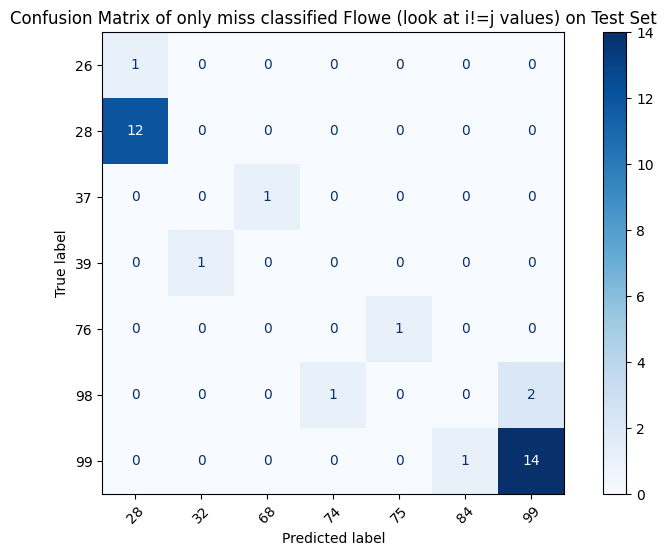

time: 272 ms (started: 2025-05-26 14:00:07 +00:00)


In [21]:
# plotting part of the confusion matrix where missclassification happened, look at i!=j values
fig, ax = plt.subplots(figsize=(10, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=sub_cm, display_labels=col_indices)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45)

# Set y-axis labels manually
disp.ax_.set_yticks(np.arange(len(row_indices)))
disp.ax_.set_yticklabels(row_indices)

plt.title("Confusion Matrix of only miss classified Flowe (look at i!=j values) on Test Set")
plt.show()

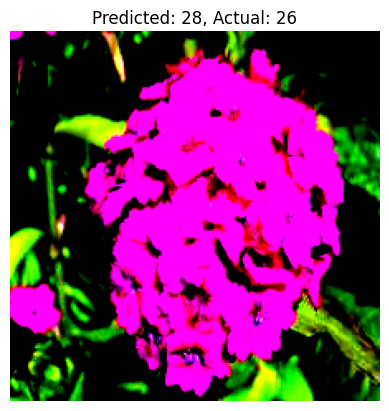

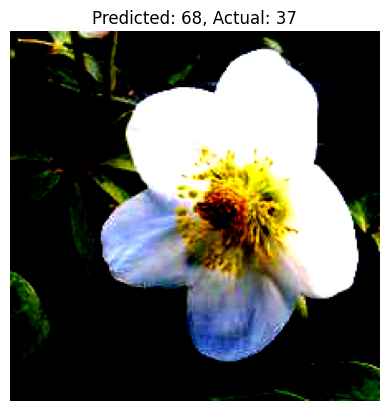

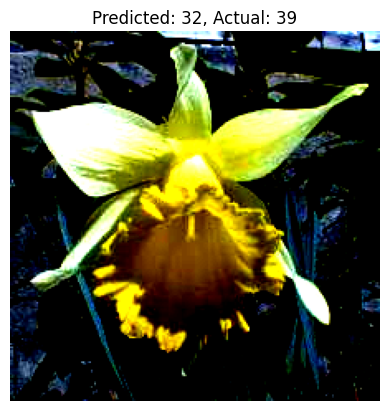

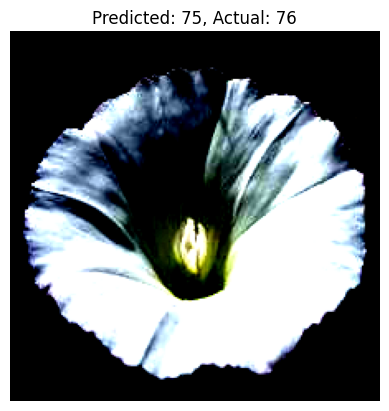

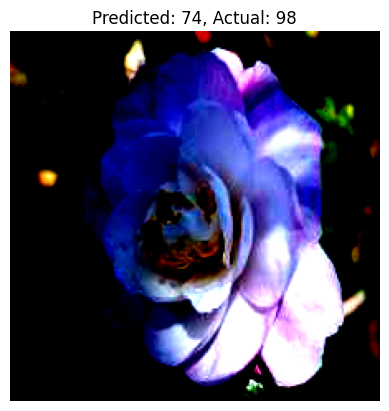

time: 554 ms (started: 2025-05-26 14:00:07 +00:00)


In [22]:
import matplotlib.pyplot as plt

# Define the number of samples to display
num_samples = 5
for i in range(num_samples):
    image = misclassified_images[i]
    pred_label = misclassified_preds[i]
    true_label = misclassified_labels[i]
    # Convert the tensor to a NumPy array and transpose to (H, W, C)
    image_np = image.permute(1, 2, 0).numpy()
    # Denormalize if necessary
    # image_np = image_np * std + mean
    plt.imshow(image_np)
    plt.title(f"Predicted: {pred_label}, Actual: {true_label}")
    plt.axis('off')
    plt.show()
